# Testing the image segmentation
- created on 8/15/2025
- ref1:https://blog.rtwilson.com/simple-segmentation-of-geospatial-images/, use RSGISLib 
- ref2:https://www.geeksforgeeks.org/machine-learning/image-segmentation-using-pythons-scikit-image-module/, use sklearn-image
- ref3:https://scikit-image.org/skimage-tutorials/lectures/4_segmentation.html

## Edited on 11/10/2025 ##

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fiona
import os
import rasterio
from rasterio.plot import show
from rasterio.mask import mask

import numpy as np
import matplotlib.pyplot as plt
from rsgislib.segmentation.shepherdseg import run_shepherd_segmentation
import skimage.data as data
import skimage.segmentation as seg
from skimage import filters
from skimage import draw
from skimage import color
from skimage import exposure

from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm  # optional, shows progress

In [3]:
# read all materials
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
# csv:trainning table, extracted values from raster
df = pd.read_csv(ra_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten_rsvalues.csv')
# raster dir and file path
ra_fp = [ra_dir + '20250711_PS_8b_mosaic.tif',
         ra_dir + '20250711_PS_8b_mosaic_ref.tif',
         ra_dir + '20250711_PS_8b_mosaic_si.tif',
         ra_dir + '20250711_PS_8b_pred.tif',
         ra_dir + '20250711_PS_8b_pred_masked.tif']

# shp file path
shp_fp = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/GIS Data/Extract data Yuwen/Shapefiles/Al_Baten_study_area.shp'

In [5]:
ref = rasterio.open(ra_fp[2])
prd = ref = rasterio.open(ra_fp[4])
print(f'the ref raster of 20250711_PS_8b_mosaic',ref.meta)
print(f'the veg cover predictions',prd.meta)

the ref raster of 20250711_PS_8b_mosaic {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}
the veg cover predictions {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 1, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}


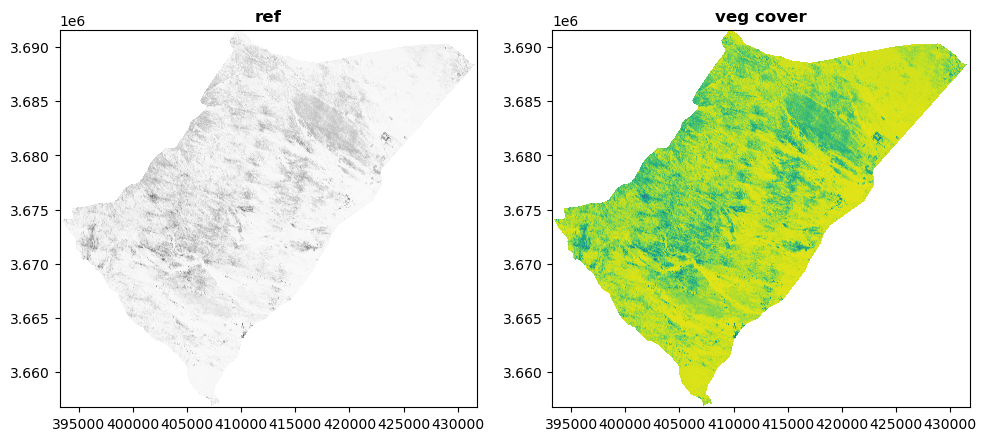

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
show((ref), ax=ax1, title="ref", cmap="Greys_r")
show((prd), ax=ax2, title="veg cover", cmap="viridis")
plt.tight_layout()
plt.show()

In [6]:
outfp_seg = [ra_dir, '20250711_PS_8b_mosaic_seg.tif',
            ra_dir, '20250711_PS_8b_si_seg.tif',
            ra_dir, '20250711_PS_8b_pred_masked_seg.tif']

In [ ]:
# Shepherd segmentation
run_shepherd_segmentation(ra_fp[4], outfp_seg[2],
                          calc_stats=False,
                          num_clusters=20,
                          min_n_pxls=300)

## extract GLCM features
- In remote sensing, the **Red and Near-Infrared (NIR) bands** are often used for vegetation analysis, with GLCM applied to these bands to extract texture features that help differentiate between crops or assess vegetation health. 

In [6]:
import rasterio
import numpy as np
from skimage.feature import graycomatrix, graycoprops
# from skimage.feature import greycomatrix, greycoprops

# Ensure the raster data is in integer format (e.g., uint8) for GLCM calculation
# If your raster has float values, you might need to quantize it first  
# Assuming 'input.tif' is your uint16 raster file
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
input_path = ra_dir + '20250711_PS_8b_mosaic.tif'
out_path = ra_dir + '20250711_PS_8b_mosaic_glcm.tif'

# Only NIR band used for GLCM calcualtion
# Define distances and angles for GLCM calculation
distances = [5]  # Consider neighboring pixels at a distance of 1
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4] # 0, 45, 90, and 135 degrees
window_size = 31  # must be odd
features = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

with rasterio.open(input_path) as src:
    # Read all bands into a 3D NumPy array
    nir_band = src.read(7) #read the NIR band
    # Get metadata for later use if needed (e.g., projection, transform)
    metadata = src.meta
    
# Optional: Preprocessing (e.g., converting to uint8 and normalizing)
# GLCM typically works with integer gray levels. You might need to scale
# your raster data to a suitable range (e.g., 0-255) if it's not already.
# Ensure the data type is integer.
nir_band_scaled = (nir_band / np.max(nir_band) * 255).astype(np.uint8)

# 2. Calculate the GLCM
# `distances`: List of distances (e.g., [50] )
# `angles`: List of angles (e.g., [0, np.pi/4, np.pi/2, 3*np.pi/4] for 0, 45, 90, 135 degrees)
# `levels`: Number of gray levels in the image (e.g., 256 for 8-bit images)
# `symmetric`: True for symmetric GLCM, False otherwise
# `normed`: True to normalize the GLCM
glcm = graycomatrix(nir_band_scaled, distances=distances, angles=angles, symmetric=True, normed=True)

In [18]:
nir_band_scaled.shape #(11619, 12850)

(11619, 12850)

In [11]:
# GLCM doesn’t return a raster the same size as your image,
# it gives you a matrix describing how often each gray level co-occurs with another gray level at the given distance and angle.

So (256, 256, 1, 4) is expected.
glcm.shape #(256, 256, 1, 4)

(256, 256, 1, 4)

In [ ]:
import rasterio
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from joblib import Parallel, delayed
from tqdm import tqdm  # optional, shows progress

# Multi-band raster. Each band corresponds to one GLCM feature:
# Band 1 → contrast
# Band 2 → dissimilarity
# Band 3 → homogeneity
# Band 4 → energy
# Band 5 → correlation
# Band 6 → ASM

# Input / Output
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
input_path = ra_dir + "20250711_PS_8b_mosaic.tif"
out_path = ra_dir + "20250711_PS_8b_glcm_features.tif"

# Parameters
distances = [5]  # distance for GLCM
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0°, 45°, 90°, 135°
window_size = 31  # must be odd
features = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

# Read NIR band
with rasterio.open(input_path) as src:
    nir_band = src.read(7).squeeze()
    meta = src.meta.copy()

# Scale to 8-bit
nir_scaled = ((nir_band / nir_band.max()) * 255).astype(np.uint8)

# Prepare output arrays
output_rasters = {f: np.zeros_like(nir_scaled, dtype=np.float32) for f in features}

# Pad array to handle borders
pad = window_size // 2
nir_padded = np.pad(nir_scaled, pad, mode="reflect")

# Loop over all pixels
rows, cols = nir_scaled.shape
for i in tqdm(range(rows), desc="Rows"):
    for j in range(cols):
        # Extract local window
        window = nir_padded[i:i+window_size, j:j+window_size]

        # Compute GLCM
        glcm = graycomatrix(window, distances=distances, angles=angles,
                            levels=256, symmetric=True, normed=True)

        # Compute features and store
        for f in features:
            output_rasters[f][i, j] = graycoprops(glcm, f).mean()

# Save all features as a multi-band GeoTIFF
meta.update(dtype=rasterio.float32, count=len(features))
with rasterio.open(out_path, "w", **meta) as dst:
    for idx, f in enumerate(features):
        dst.write(output_rasters[f], idx + 1)

print("Saved GLCM feature rasters:", out_path)

In [ ]:
import rasterio
import numpy as np
from skimage.feature import graycomatrix, graycoprops
from joblib import Parallel, delayed
from tqdm import tqdm  # progress bar

# Input / output
input_path = ra_dir + "20250711_PS_8b_mosaic.tif"
out_path = ra_dir + "20250711_PS_8b_glcm_features.tif"

# Parameters
distances = [5]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
window_size = 31  # odd number
features = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
n_jobs = -1  # use all CPU cores

# Read NIR band
with rasterio.open(input_path) as src:
    nir_band = src.read(7).squeeze()
    meta = src.meta.copy()

# Scale to uint8
nir_scaled = ((nir_band / nir_band.max()) * 255).astype(np.uint8)

# Pad array for border handling
pad = window_size // 2
nir_padded = np.pad(nir_scaled, pad, mode="reflect")

rows, cols = nir_scaled.shape

# Function to compute GLCM features for one pixel
def compute_pixel(i, j):
    window = nir_padded[i:i+window_size, j:j+window_size]
    glcm = graycomatrix(window, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)
    return [graycoprops(glcm, f).mean() for f in features]

# Prepare coordinates of all pixels
coords = [(i, j) for i in range(rows) for j in range(cols)]

# Parallel computation
results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(compute_pixel)(i, j) for i, j in coords
)

# Reshape results into raster layers
results = np.array(results)  # shape: (rows*cols, num_features)
results = results.reshape(rows, cols, len(features))

# Save each feature as a band in GeoTIFF
meta.update(dtype=rasterio.float32, count=len(features))
with rasterio.open(out_path, "w", **meta) as dst:
    for idx, f in enumerate(features):
        dst.write(results[:, :, idx].astype(np.float32), idx + 1)

print("Saved GLCM feature rasters (parallelized):", out_path)


In [21]:
dst.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0.0,
 'width': 12850,
 'height': 11619,
 'count': 6,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [24]:
with rasterio.open(out_path) as src:
    contrast = src.read(1)  # Read the first band

df_contrast = contrast.flatten()

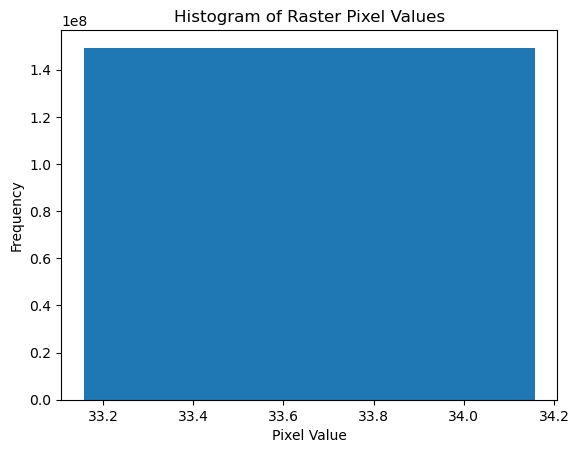

In [26]:
# creat a hist graph
hist_values, bin_edges = np.histogram(df_contrast, bins='auto') # 'auto' determines optimal bin size

plt.hist(df_contrast, bins='auto')
plt.title('Histogram of Raster Pixel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# https://github.com/alfianhid/Feature-Extraction-Gray-Level-Co-occurrence-Matrix-GLCM-with-Python/blob/master/Feature_Extraction_Gray_Level_Co_occurrence_Matrix_(GLCM)_with_Python.ipynb
# referencing for conducting GLCM
from skimage.feature import greycomatrix, greycoprops

# ----------------- calculate greycomatrix() & greycoprops() for angle 0, 45, 90, 135 ----------------------------------
def calc_glcm_all_agls(img, label, props, dists=[5], agls=[0, np.pi/4, np.pi/2, 3*np.pi/4], lvl=256, sym=True, norm=True):
    
    glcm = greycomatrix(img, 
                        distances=dists, 
                        angles=agls, 
                        levels=lvl,
                        symmetric=sym, 
                        normed=norm)
    feature = []
    glcm_props = [propery for name in props for propery in greycoprops(glcm, name)[0]]
    for item in glcm_props:
            feature.append(item)
    feature.append(label) 
    
    return feature

# ----------------- call calc_glcm_all_agls() for all properties ----------------------------------
properties = ['dissimilarity', 'correlation', 'homogeneity', 'contrast', 'ASM', 'energy']

glcm_all_agls = []
for img, label in zip(imgs, labels): 
    glcm_all_agls.append(
            calc_glcm_all_agls(img, 
                                label, 
                                props=properties)
                            )
 
columns = []
angles = ['0', '45', '90','135']
for name in properties :
    for ang in angles:
        columns.append(name + "_" + ang)
        
columns.append("label")

# Create the pandas DataFrame for GLCM features data
glcm_df = pd.DataFrame(glcm_all_agls, 
                      columns = columns)

glcm_df.head(15)

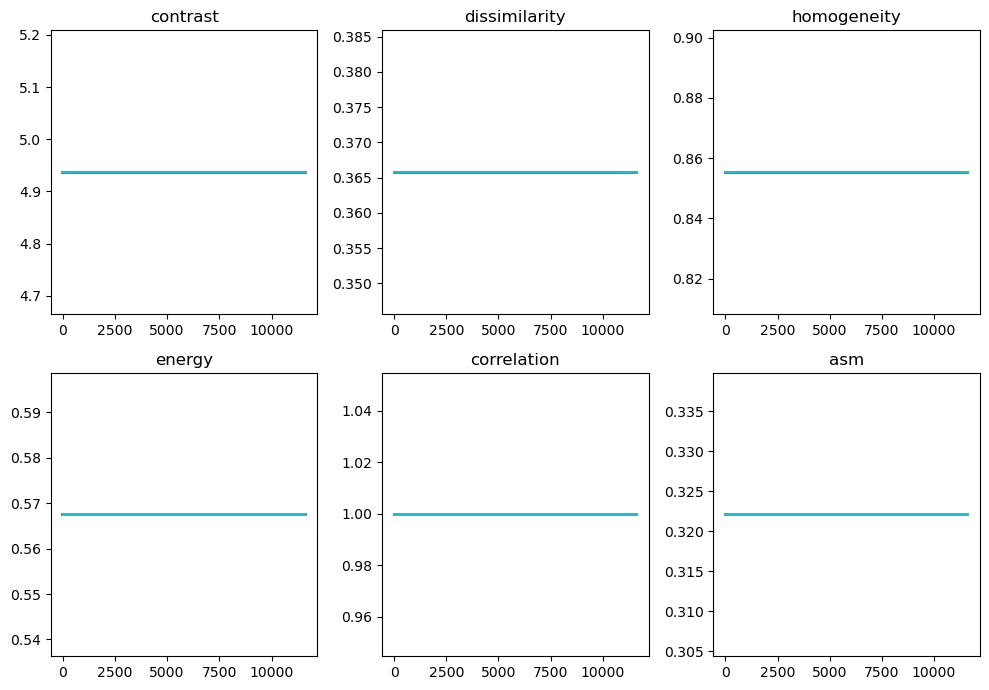

In [30]:
# Create a figure and a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(10, 7)) # figsize adjusts the overall size of the figure

# Access individual subplots and plot data
# axs is a 2D array, so use indexing like axs[row, col]
# Plot on the first subplot (top-left)
axs[0, 0].plot(contrast_array, label='contrast')
axs[0, 0].set_title('contrast')

# Plot on the second subplot (top-middle)
axs[0, 1].plot(dissimilarity_array, label='dissimilarity')
axs[0, 1].set_title('dissimilarity')

# Plot on the third subplot (top-right)
axs[0, 2].plot(homogeneity_array, label='homogeneity')
axs[0, 2].set_title('homogeneity')

# Plot on the fourth subplot (bottom-left)
axs[1, 0].plot(energy_array)
axs[1, 0].set_title('energy')

# Plot on the fifth subplot (bottom-middle)
axs[1, 1].plot(correlation_array)
axs[1, 1].set_title('correlation')

# Plot on the sixth subplot (bottom-right)
axs[1, 2].plot(asm_array)
axs[1, 2].set_title('asm')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plots
plt.show()